# **EXPLORACIÓN Y DESCRIPCIÓN DE LOS DATOS**

## **1. Instalación e imports**

In [1]:
!pip -q install kagglehub

from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import warnings

import kagglehub
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Se mejora la visualización de pandas y matplotlib para inspección en Colab.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 6)

## **2. Descarga de datasets y rutas principales**

In [2]:
# Se descargan los datasets desde KaggleHub.
# Si Colab solicita autenticación de Kaggle, se debe cargar el kaggle.json correspondiente.
anomaly_path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")
print("Path to anomaly dataset files:", anomaly_path)

contraband_path = kagglehub.dataset_download(
    "nikitamanaenkov/x-ray-contraband-detection-dataset"
)
print("Path to contraband dataset files:", contraband_path)

100%|██████████| 133M/133M [00:02<00:00, 58.7MB/s]

Extracting files...


Path to anomaly dataset files: /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1


100%|██████████| 1.12G/1.12G [00:10<00:00, 113MB/s] 

Extracting files...


Path to contraband dataset files: /root/.cache/kagglehub/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/versions/1


## **3. Funciones auxiliares de uso general**

In [3]:
# Se definen extensiones válidas de imagen.
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def get_all_image_paths(root_path):
    """
    Se recopilan todas las rutas de imágenes bajo el directorio raíz.
    """
    root = Path(root_path)
    image_paths = [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
    return sorted(image_paths)

def compute_file_hash(file_path, chunk_size=8192):
    """
    Se calcula un hash SHA-256 del archivo para detectar duplicados exactos.
    """
    sha256 = hashlib.sha256()
    with open(file_path, "rb") as f:
        while True:
            data = f.read(chunk_size)
            if not data:
                break
            sha256.update(data)
    return sha256.hexdigest()

def safe_read_gray(img_path):
    """
    Se intenta leer una imagen en escala de grises.
    Si la lectura falla, se retorna None.
    """
    img = cv.imread(str(img_path), cv.IMREAD_GRAYSCALE)
    return img

def image_entropy(img_gray):
    """
    Se calcula la entropía de Shannon sobre la distribución de intensidades.
    """
    hist = cv.calcHist([img_gray], [0], None, [256], [0, 256]).ravel()
    prob = hist / hist.sum() if hist.sum() > 0 else hist
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob)) if len(prob) > 0 else 0.0

def blur_score_laplacian(img_gray):
    """
    Se estima el nivel de nitidez mediante la varianza del Laplacian.
    Valores bajos suelen asociarse a imágenes más borrosas.
    """
    return cv.Laplacian(img_gray, cv.CV_64F).var()

def edge_density_canny(img_gray, low=100, high=200):
    """
    Se calcula la proporción de píxeles activados por Canny.
    Esto sirve como aproximación a complejidad estructural.
    """
    edges = cv.Canny(img_gray, low, high)
    return float(np.mean(edges > 0))

def summarize_folder_structure(root_path, name):
    """
    Se resume la estructura de carpetas y el conteo de imágenes por subdirectorio.
    """
    print(f"\n{'='*80}")
    print(f"Folder structure summary: {name}")
    print(f"{'='*80}")

    root = Path(root_path)
    folder_counts = []

    for subdir in sorted(root.glob("**/")):
        try:
            images = [f for f in subdir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS]
            if images:
                folder_counts.append(
                    {
                        "folder": str(subdir.relative_to(root)),
                        "n_images": len(images),
                    }
                )
        except PermissionError:
            continue

    if folder_counts:
        df = pd.DataFrame(folder_counts).sort_values("folder").reset_index(drop=True)
        display(df)
        print(f"Total folders with images: {len(df)}")
        print(f"Total images counted across folders: {df['n_images'].sum()}")
    else:
        print("No folders with images were found.")

def find_label_files(root_path):
    """
    Se buscan archivos de anotaciones en formato YOLO (.txt).
    Se excluyen archivos potencialmente irrelevantes de configuración cuando sea posible.
    """
    root = Path(root_path)
    label_files = []
    for p in root.rglob("*.txt"):
        # Se excluyen archivos muy comunes de metadata o documentación.
        if p.name.lower() in {"readme.txt", "classes.txt"}:
            continue
        label_files.append(p)
    return sorted(label_files)

## **4. Resumen visual básico del dataset completo**


Visual summary: Anomaly Detection Dataset
Folder: test/images | Images: 883
Folder: train/images | Images: 6181
Folder: valid/images | Images: 1766


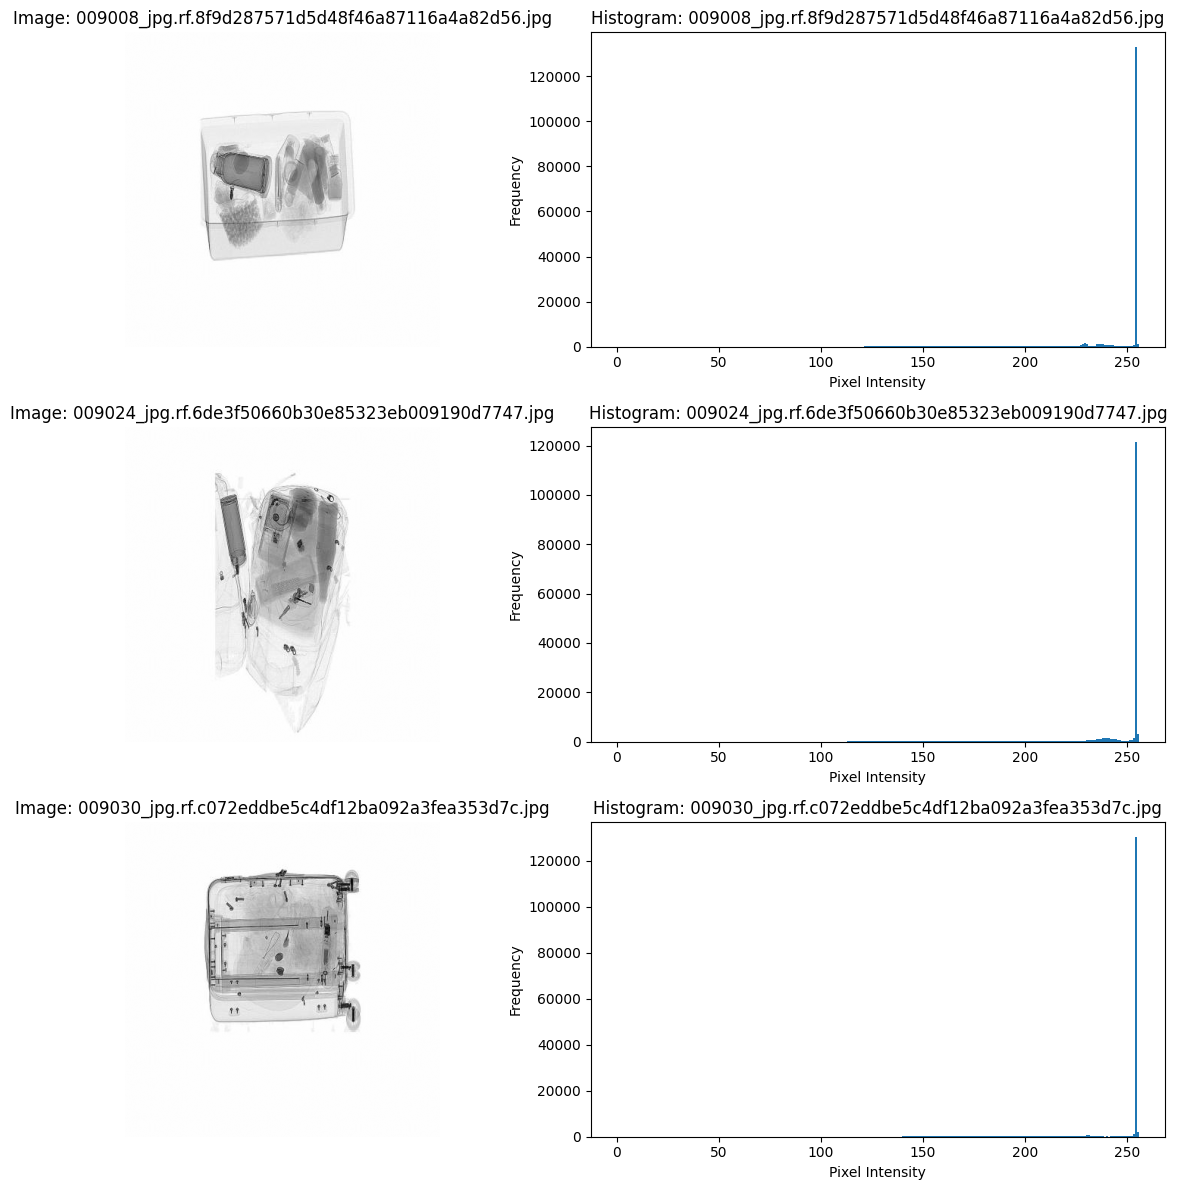


Visual summary: Contraband Detection Dataset
Folder: data/images/test | Images: 1373
Folder: data/images/train | Images: 10982
Folder: data/images/val | Images: 1373


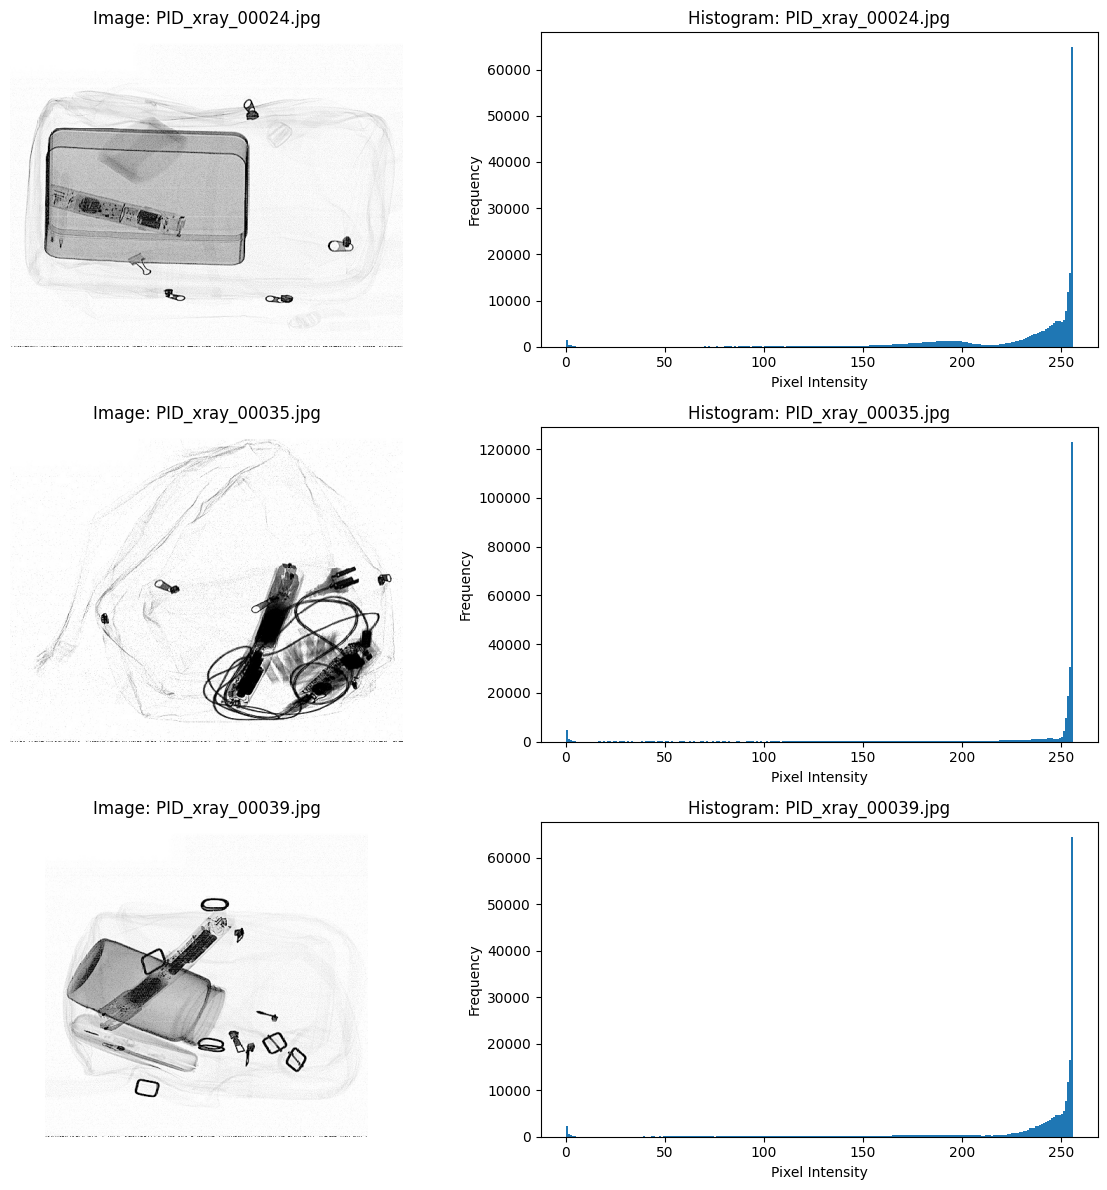

In [4]:
def summarize_with_images(root_path, name, n_samples=3):
    """
    Se muestra la estructura por carpetas y una pequeña muestra visual
    con histogramas de intensidad.
    """
    print(f"\n{'='*80}")
    print(f"Visual summary: {name}")
    print(f"{'='*80}")

    root = Path(root_path)
    image_paths = get_all_image_paths(root)

    # Se imprime conteo por carpeta.
    for subdir in sorted(root.glob("**/")):
        try:
            images = [f for f in subdir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS]
            if images:
                print(f"Folder: {subdir.relative_to(root)} | Images: {len(images)}")
        except PermissionError:
            continue

    # Se toma una pequeña muestra representativa inicial para inspección visual.
    sample_images = image_paths[:n_samples]

    if sample_images:
        fig, axes = plt.subplots(len(sample_images), 2, figsize=(12, 4 * len(sample_images)))

        if len(sample_images) == 1:
            axes = np.array([axes])

        for i, img_path in enumerate(sample_images):
            img = safe_read_gray(img_path)
            if img is not None:
                axes[i][0].imshow(img, cmap="gray")
                axes[i][0].set_title(f"Image: {img_path.name}")
                axes[i][0].axis("off")

                axes[i][1].hist(img.ravel(), bins=256, range=[0, 256])
                axes[i][1].set_title(f"Histogram: {img_path.name}")
                axes[i][1].set_xlabel("Pixel Intensity")
                axes[i][1].set_ylabel("Frequency")
            else:
                axes[i][0].set_title(f"Unreadable: {img_path.name}")
                axes[i][0].axis("off")
                axes[i][1].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No images found for visual summary.")


summarize_with_images(anomaly_path, "Anomaly Detection Dataset")
summarize_with_images(contraband_path, "Contraband Detection Dataset")

## **5. Estadísticas sobre las imágenes**


Statistical deep-dive: Anomaly Dataset
Processed 2000/8830 images...
Processed 4000/8830 images...
Processed 6000/8830 images...
Processed 8000/8830 images...


,dataset,total_images_found,total_images_readable,total_images_corrupt,exact_duplicate_files,global_mean_brightness,global_std_brightness,global_mean_contrast_rms,global_std_contrast_rms,global_mean_entropy,global_mean_blur_laplacian,global_mean_edge_density,avg_height,avg_width,median_height,median_width,avg_aspect_ratio,unique_shapes
0,Anomaly Dataset,8830,8830,0,0,233.627153,8.559916,39.614509,8.386054,3.350966,1268.324172,0.04471,416.0,416.0,416.0,416.0,1.0,1


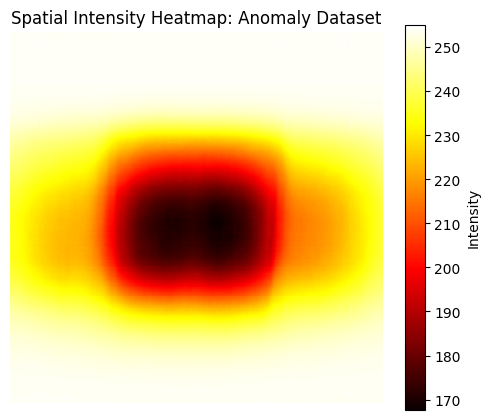

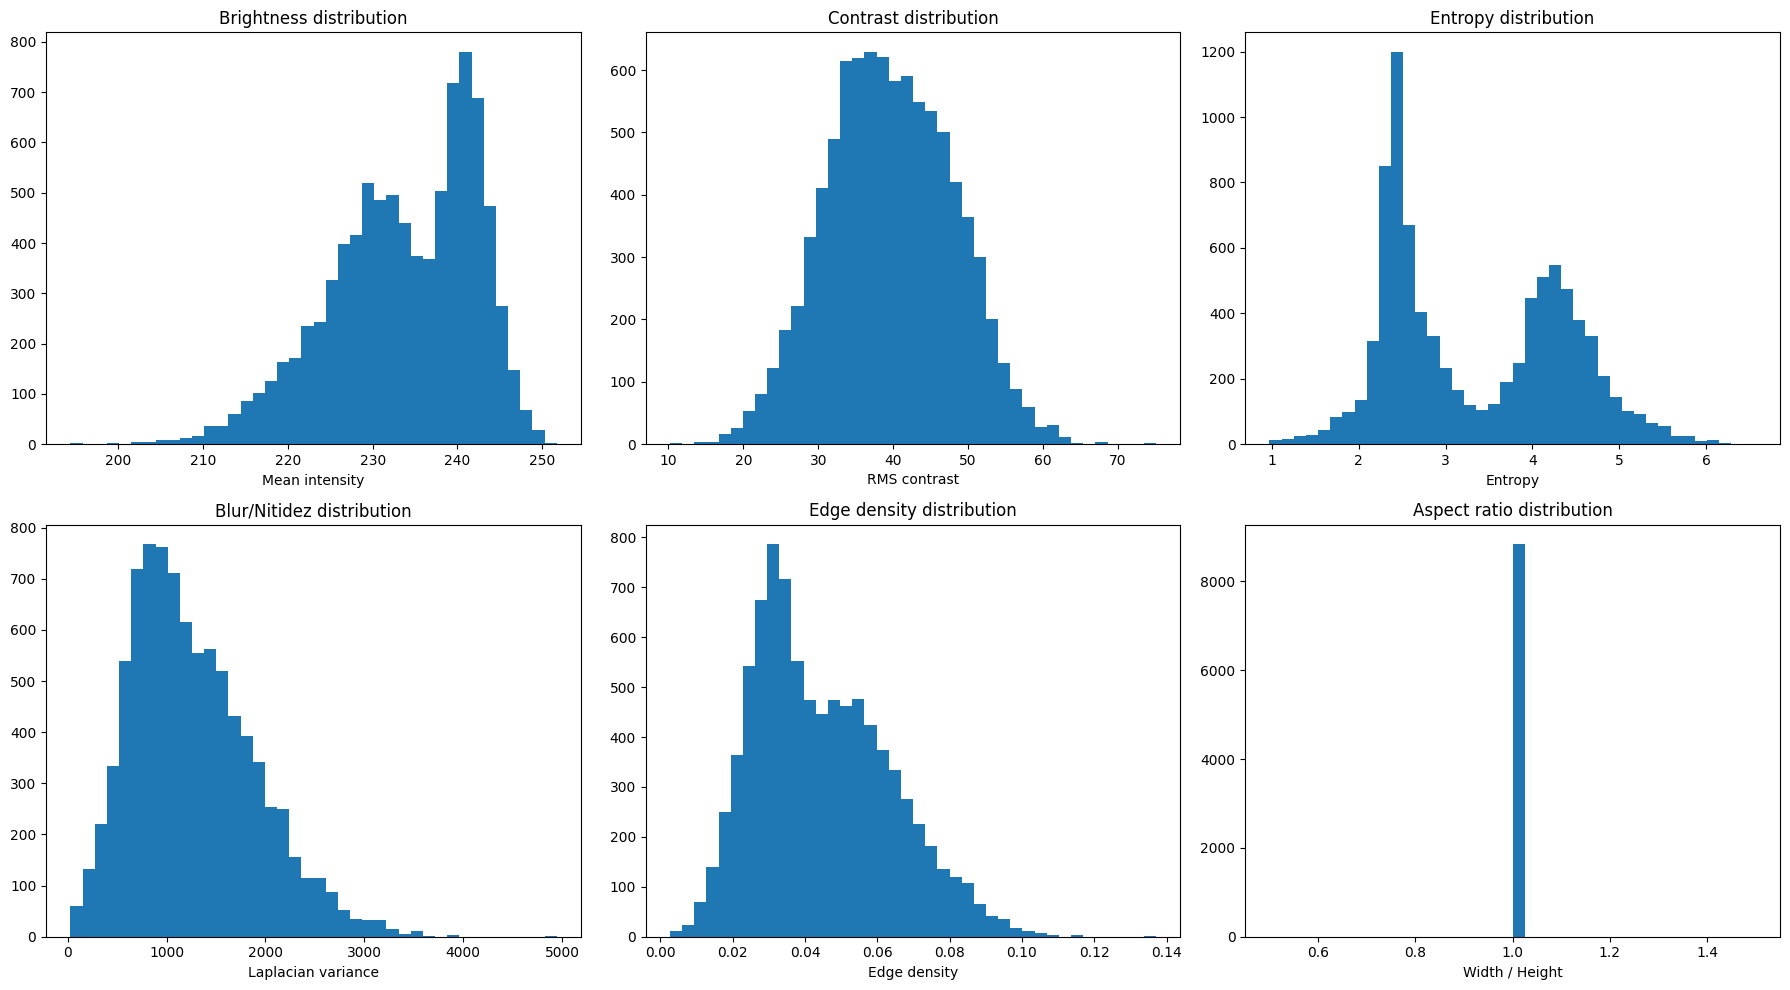


Descriptive statistics:


,count,mean,std,min,5%,25%,50%,75%,95%,max
brightness,8830.0,233.627153,8.560401,194.346974,218.021713,227.917220,234.539559,240.702609,244.840922,251.704217
contrast_rms,8830.0,39.614509,8.386529,10.201842,26.122758,33.702483,39.351988,45.672377,53.222382,75.088854
entropy,8830.0,3.350966,1.026614,0.974031,2.093636,2.436436,3.054452,4.253636,4.974095,6.567558
blur_laplacian,8830.0,1268.324172,625.981768,27.276835,409.379869,797.825499,1166.566896,1657.531540,2430.779103,4946.827713
edge_density,8830.0,0.044710,0.018786,0.002670,0.018817,0.030130,0.041796,0.057580,0.079138,0.137106
height,8830.0,416.000000,0.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000
width,8830.0,416.000000,0.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000
aspect_ratio,8830.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Statistical deep-dive: Contraband Dataset
Processed 2000/13728 images...
Processed 4000/13728 images...
Processed 6000/13728 images...
Processed 8000/13728 images...
Processed 10000/13728 images...
Processed 12000/13728 images...


,dataset,total_images_found,total_images_readable,total_images_corrupt,exact_duplicate_files,global_mean_brightness,global_std_brightness,global_mean_contrast_rms,global_std_contrast_rms,global_mean_entropy,global_mean_blur_laplacian,global_mean_edge_density,avg_height,avg_width,median_height,median_width,avg_aspect_ratio,unique_shapes
0,Contraband Dataset,13728,13728,0,17,219.323415,17.719275,57.647088,14.452052,4.532667,2578.085098,0.052136,482.976836,497.655522,448.0,457.5,1.031976,1579


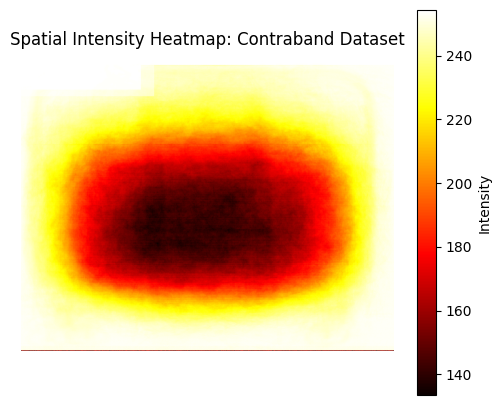

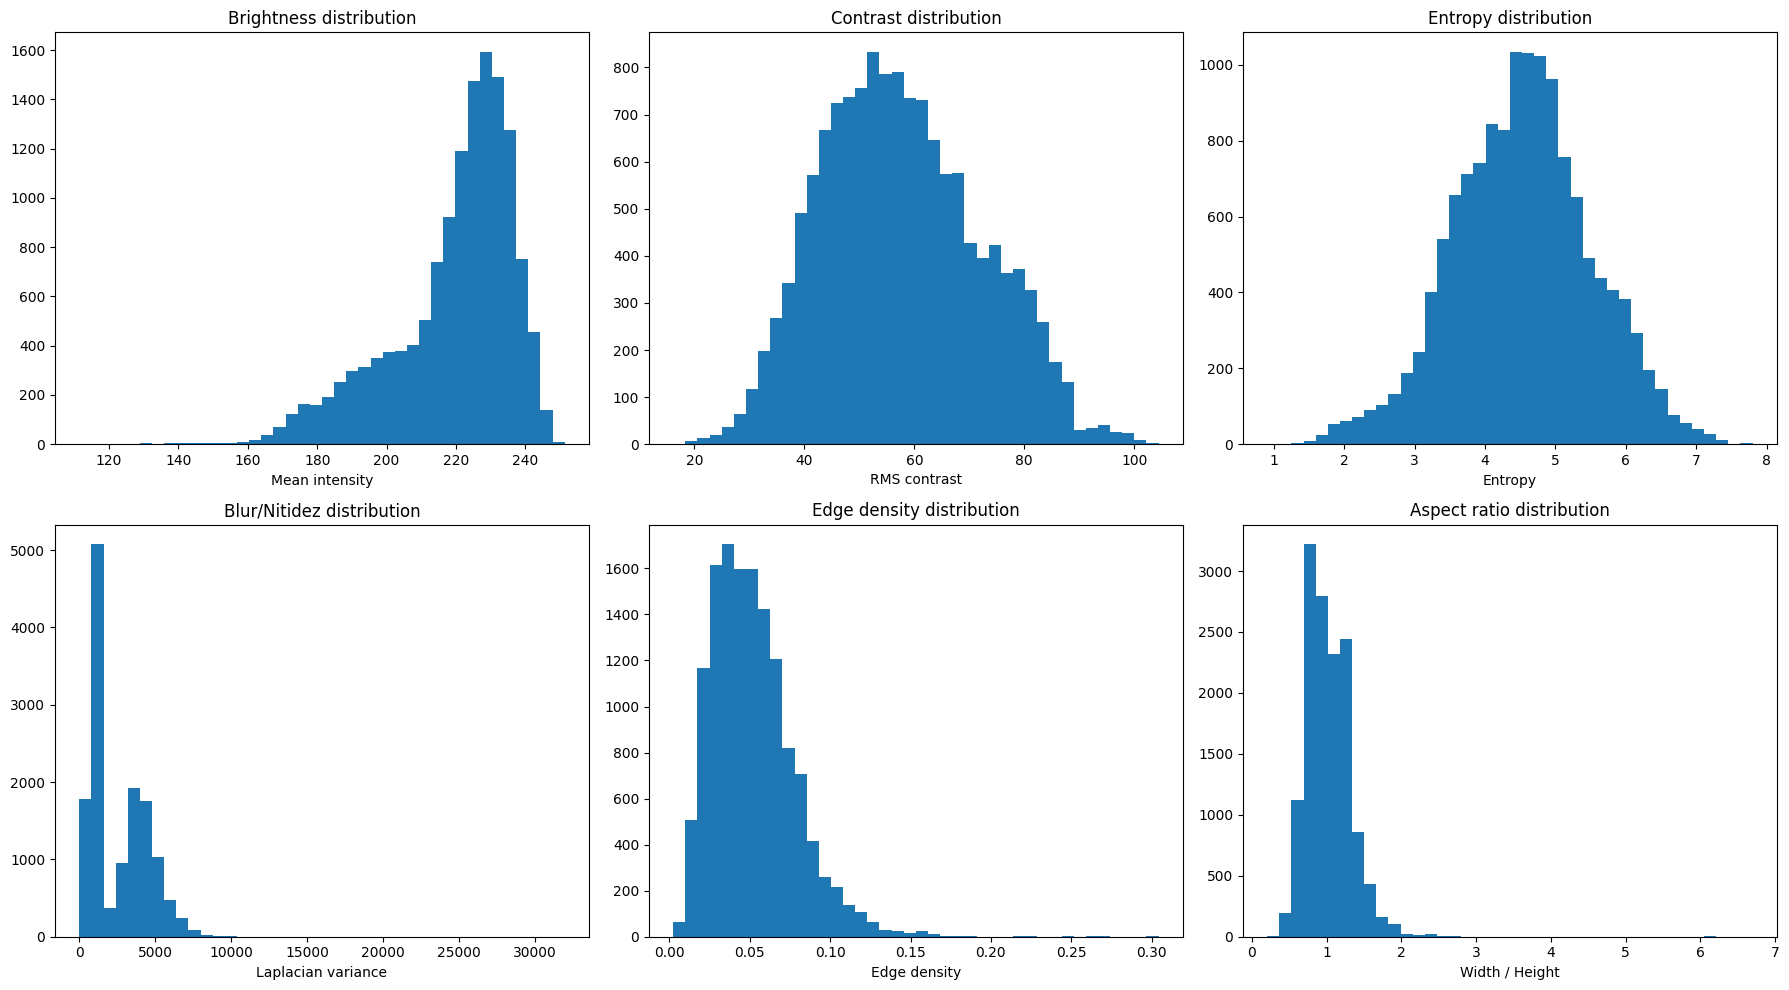


Descriptive statistics:


,count,mean,std,min,5%,25%,50%,75%,95%,max
brightness,13728.0,219.323415,17.719921,111.403559,182.728594,211.173400,224.242495,231.839437,240.387031,251.341594
contrast_rms,13728.0,57.647088,14.452578,16.151587,35.725442,46.780729,56.501269,67.672033,82.656419,104.424301
entropy,13728.0,4.532667,0.978807,0.908162,2.928655,3.867936,4.544783,5.156060,6.165331,7.798071
blur_laplacian,13728.0,2578.085098,1920.542923,5.043728,406.536248,980.818759,1614.997600,4083.987055,5831.477143,31944.563504
edge_density,13728.0,0.052136,0.025726,0.002455,0.018599,0.032998,0.048741,0.066265,0.099386,0.304253
height,13728.0,482.976836,127.300020,144.000000,448.000000,448.000000,448.000000,448.000000,731.650000,1330.000000
width,13728.0,497.655522,211.076199,140.000000,300.000000,380.000000,457.500000,580.000000,806.650000,3000.000000
aspect_ratio,13728.0,1.031976,0.304901,0.203846,0.625000,0.803571,0.982143,1.250000,1.564375,6.696429


In [5]:
def calculate_advanced_stats(root_path, name):
    """
    Se calculan estadísticas avanzadas sobre todas las imágenes del dataset:
    brightness, contrast, entropy, blur, edge density, dimensiones y duplicados.
    """
    print(f"\n{'='*80}")
    print(f"Statistical deep-dive: {name}")
    print(f"{'='*80}")

    root = Path(root_path)
    image_paths = get_all_image_paths(root)

    if not image_paths:
        print("No images found.")
        return None

    brightness_vals = []
    contrast_vals = []
    entropy_vals = []
    blur_vals = []
    edge_density_vals = []

    heights = []
    widths = []
    aspect_ratios = []

    corrupt_images = []
    hash_counter = Counter()

    avg_img = None
    avg_img_count = 0
    reference_shape = None

    # Se recorre la totalidad de imágenes del dataset.
    for idx, p in enumerate(image_paths, start=1):
        img = safe_read_gray(p)

        if img is None:
            corrupt_images.append(str(p))
            continue

        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)
        aspect_ratios.append(w / h if h > 0 else np.nan)

        brightness_vals.append(float(np.mean(img)))
        contrast_vals.append(float(np.std(img)))
        entropy_vals.append(float(image_entropy(img)))
        blur_vals.append(float(blur_score_laplacian(img)))
        edge_density_vals.append(float(edge_density_canny(img)))

        # Se intenta construir una imagen promedio únicamente para imágenes con forma homogénea.
        if reference_shape is None:
            reference_shape = img.shape
            avg_img = np.zeros(reference_shape, dtype=np.float64)

        if img.shape == reference_shape:
            avg_img += img.astype(np.float64)
            avg_img_count += 1

        # Se calcula hash del archivo para detectar duplicados exactos.
        try:
            file_hash = compute_file_hash(p)
            hash_counter[file_hash] += 1
        except Exception:
            pass

        if idx % 2000 == 0:
            print(f"Processed {idx}/{len(image_paths)} images...")

    duplicates_exact = sum(v - 1 for v in hash_counter.values() if v > 1)

    stats = {
        "dataset": name,
        "total_images_found": len(image_paths),
        "total_images_readable": len(brightness_vals),
        "total_images_corrupt": len(corrupt_images),
        "exact_duplicate_files": duplicates_exact,
        "global_mean_brightness": np.mean(brightness_vals) if brightness_vals else np.nan,
        "global_std_brightness": np.std(brightness_vals) if brightness_vals else np.nan,
        "global_mean_contrast_rms": np.mean(contrast_vals) if contrast_vals else np.nan,
        "global_std_contrast_rms": np.std(contrast_vals) if contrast_vals else np.nan,
        "global_mean_entropy": np.mean(entropy_vals) if entropy_vals else np.nan,
        "global_mean_blur_laplacian": np.mean(blur_vals) if blur_vals else np.nan,
        "global_mean_edge_density": np.mean(edge_density_vals) if edge_density_vals else np.nan,
        "avg_height": np.mean(heights) if heights else np.nan,
        "avg_width": np.mean(widths) if widths else np.nan,
        "median_height": np.median(heights) if heights else np.nan,
        "median_width": np.median(widths) if widths else np.nan,
        "avg_aspect_ratio": np.mean(aspect_ratios) if aspect_ratios else np.nan,
        "unique_shapes": len(set(zip(heights, widths))) if heights and widths else 0,
    }

    stats_df = pd.DataFrame([stats])
    display(stats_df)

    if corrupt_images:
        print("\nUnreadable or corrupt images detected:")
        for p in corrupt_images[:10]:
            print(p)
        if len(corrupt_images) > 10:
            print(f"... and {len(corrupt_images) - 10} more")

    # Se grafica la imagen promedio solo si hubo suficientes imágenes con la misma resolución.
    if avg_img_count > 0:
        avg_img_display = avg_img / avg_img_count

        plt.figure(figsize=(6, 5))
        plt.imshow(avg_img_display, cmap="hot")
        plt.colorbar(label="Intensity")
        plt.title(f"Spatial Intensity Heatmap: {name}")
        plt.axis("off")
        plt.show()

    # Se muestran distribuciones principales.
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].hist(brightness_vals, bins=40)
    axes[0, 0].set_title("Brightness distribution")
    axes[0, 0].set_xlabel("Mean intensity")

    axes[0, 1].hist(contrast_vals, bins=40)
    axes[0, 1].set_title("Contrast distribution")
    axes[0, 1].set_xlabel("RMS contrast")

    axes[0, 2].hist(entropy_vals, bins=40)
    axes[0, 2].set_title("Entropy distribution")
    axes[0, 2].set_xlabel("Entropy")

    axes[1, 0].hist(blur_vals, bins=40)
    axes[1, 0].set_title("Blur/Nitidez distribution")
    axes[1, 0].set_xlabel("Laplacian variance")

    axes[1, 1].hist(edge_density_vals, bins=40)
    axes[1, 1].set_title("Edge density distribution")
    axes[1, 1].set_xlabel("Edge density")

    axes[1, 2].hist(aspect_ratios, bins=40)
    axes[1, 2].set_title("Aspect ratio distribution")
    axes[1, 2].set_xlabel("Width / Height")

    plt.tight_layout()
    plt.show()

    # Se muestran algunas estadísticas descriptivas consolidadas.
    metrics_df = pd.DataFrame({
        "brightness": brightness_vals,
        "contrast_rms": contrast_vals,
        "entropy": entropy_vals,
        "blur_laplacian": blur_vals,
        "edge_density": edge_density_vals,
        "height": heights,
        "width": widths,
        "aspect_ratio": aspect_ratios
    })

    print("\nDescriptive statistics:")
    display(metrics_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

    return {
        "summary": stats_df,
        "metrics": metrics_df,
        "corrupt_images": corrupt_images
    }


anomaly_stats = calculate_advanced_stats(anomaly_path, "Anomaly Dataset")
contraband_stats = calculate_advanced_stats(contraband_path, "Contraband Dataset")

## **6. Análisis visual avanzado de computer vision**


Advanced CV analysis: Anomaly Dataset
Average dimensions (all readable images): 416.0 x 416.0
Unique image shapes: 1


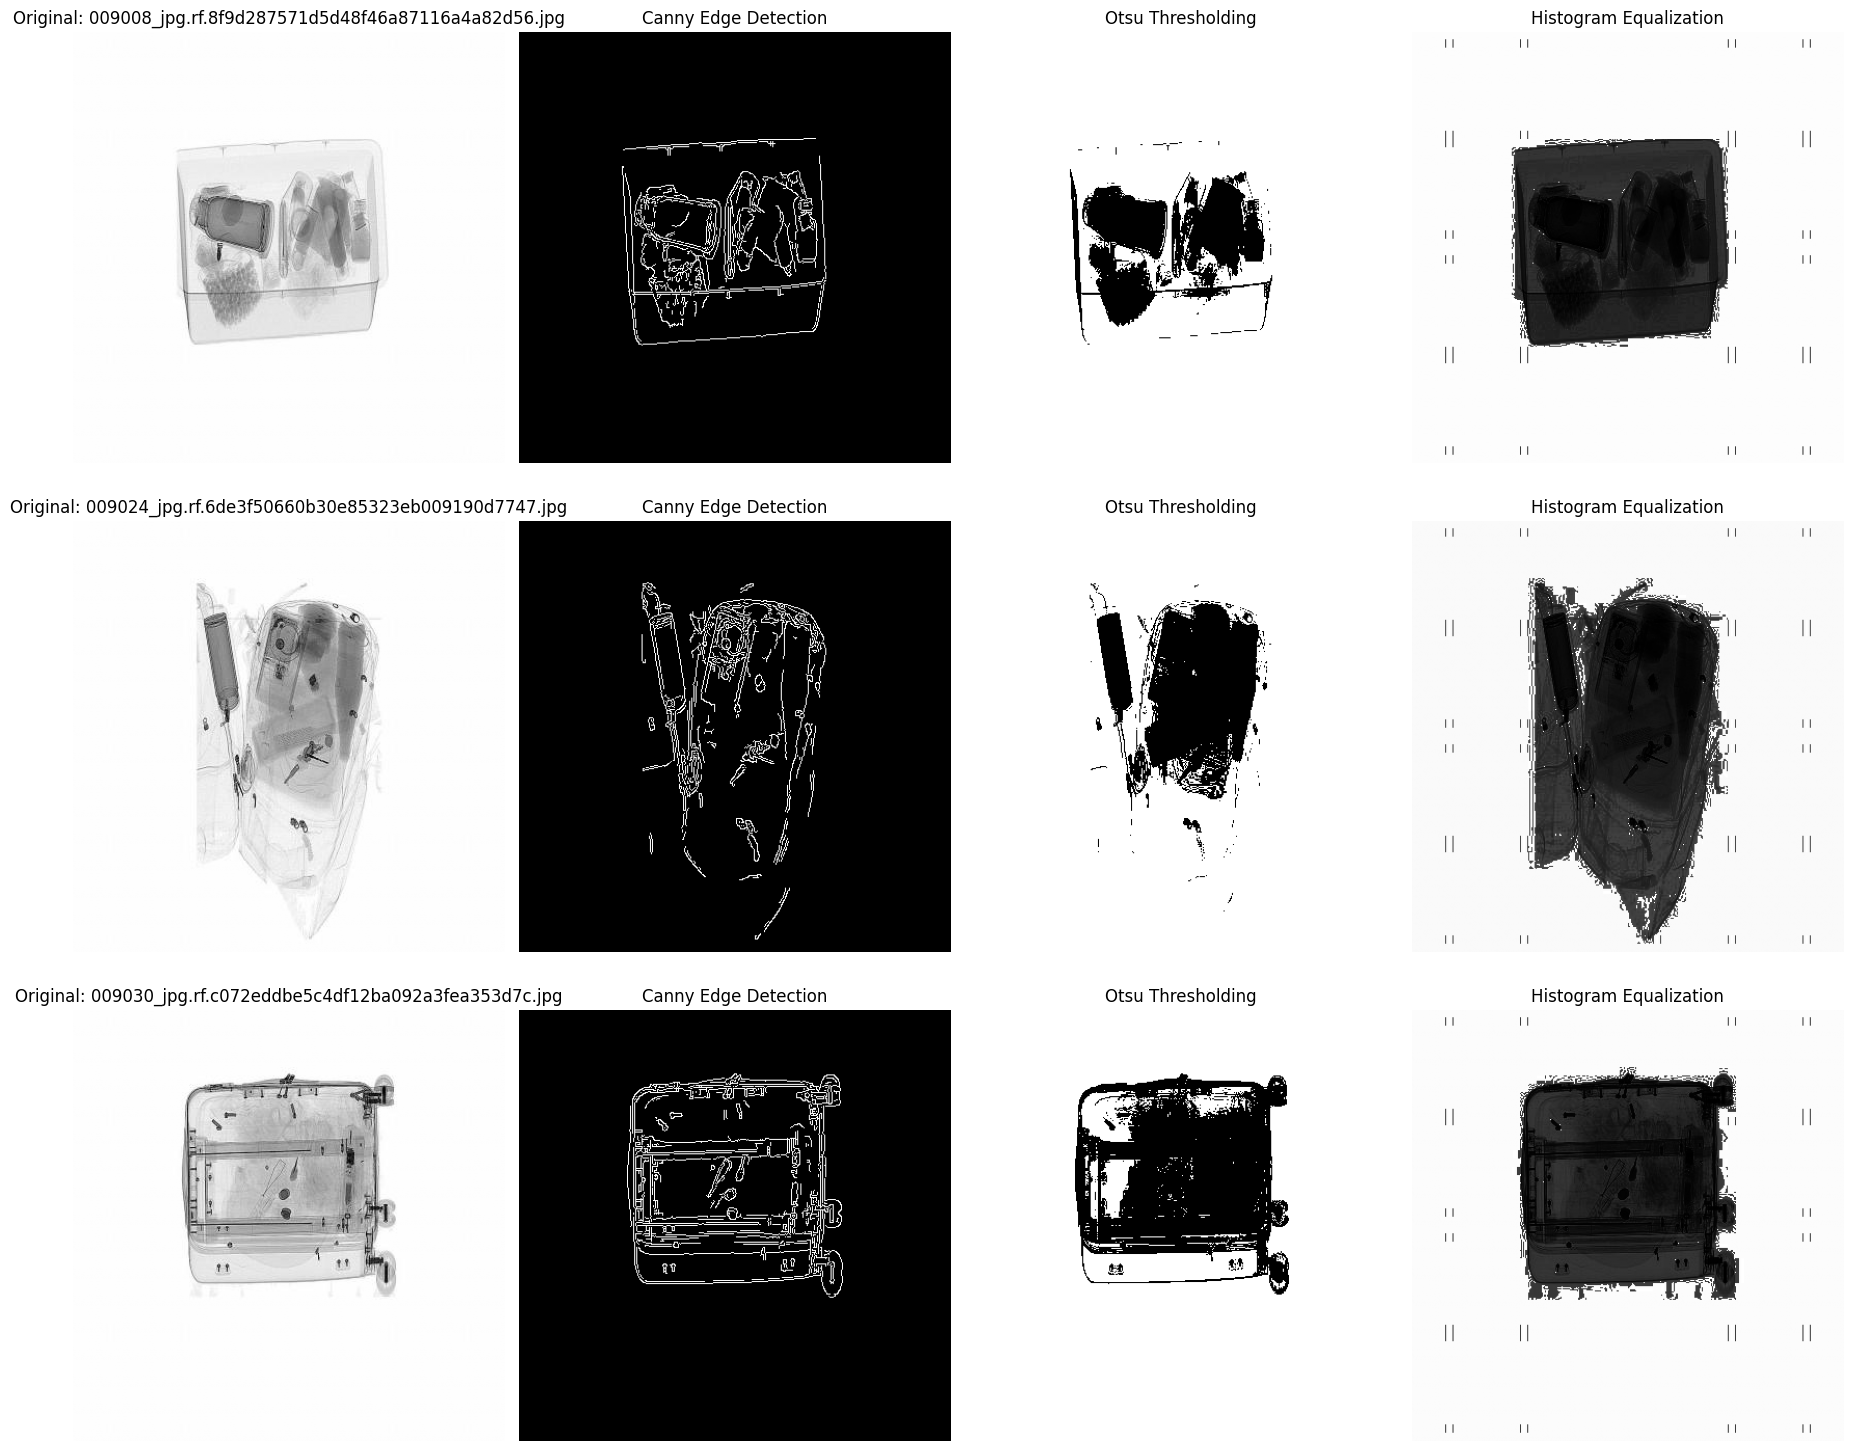


Advanced CV analysis: Contraband Dataset
Average dimensions (all readable images): 497.7 x 483.0
Unique image shapes: 1579


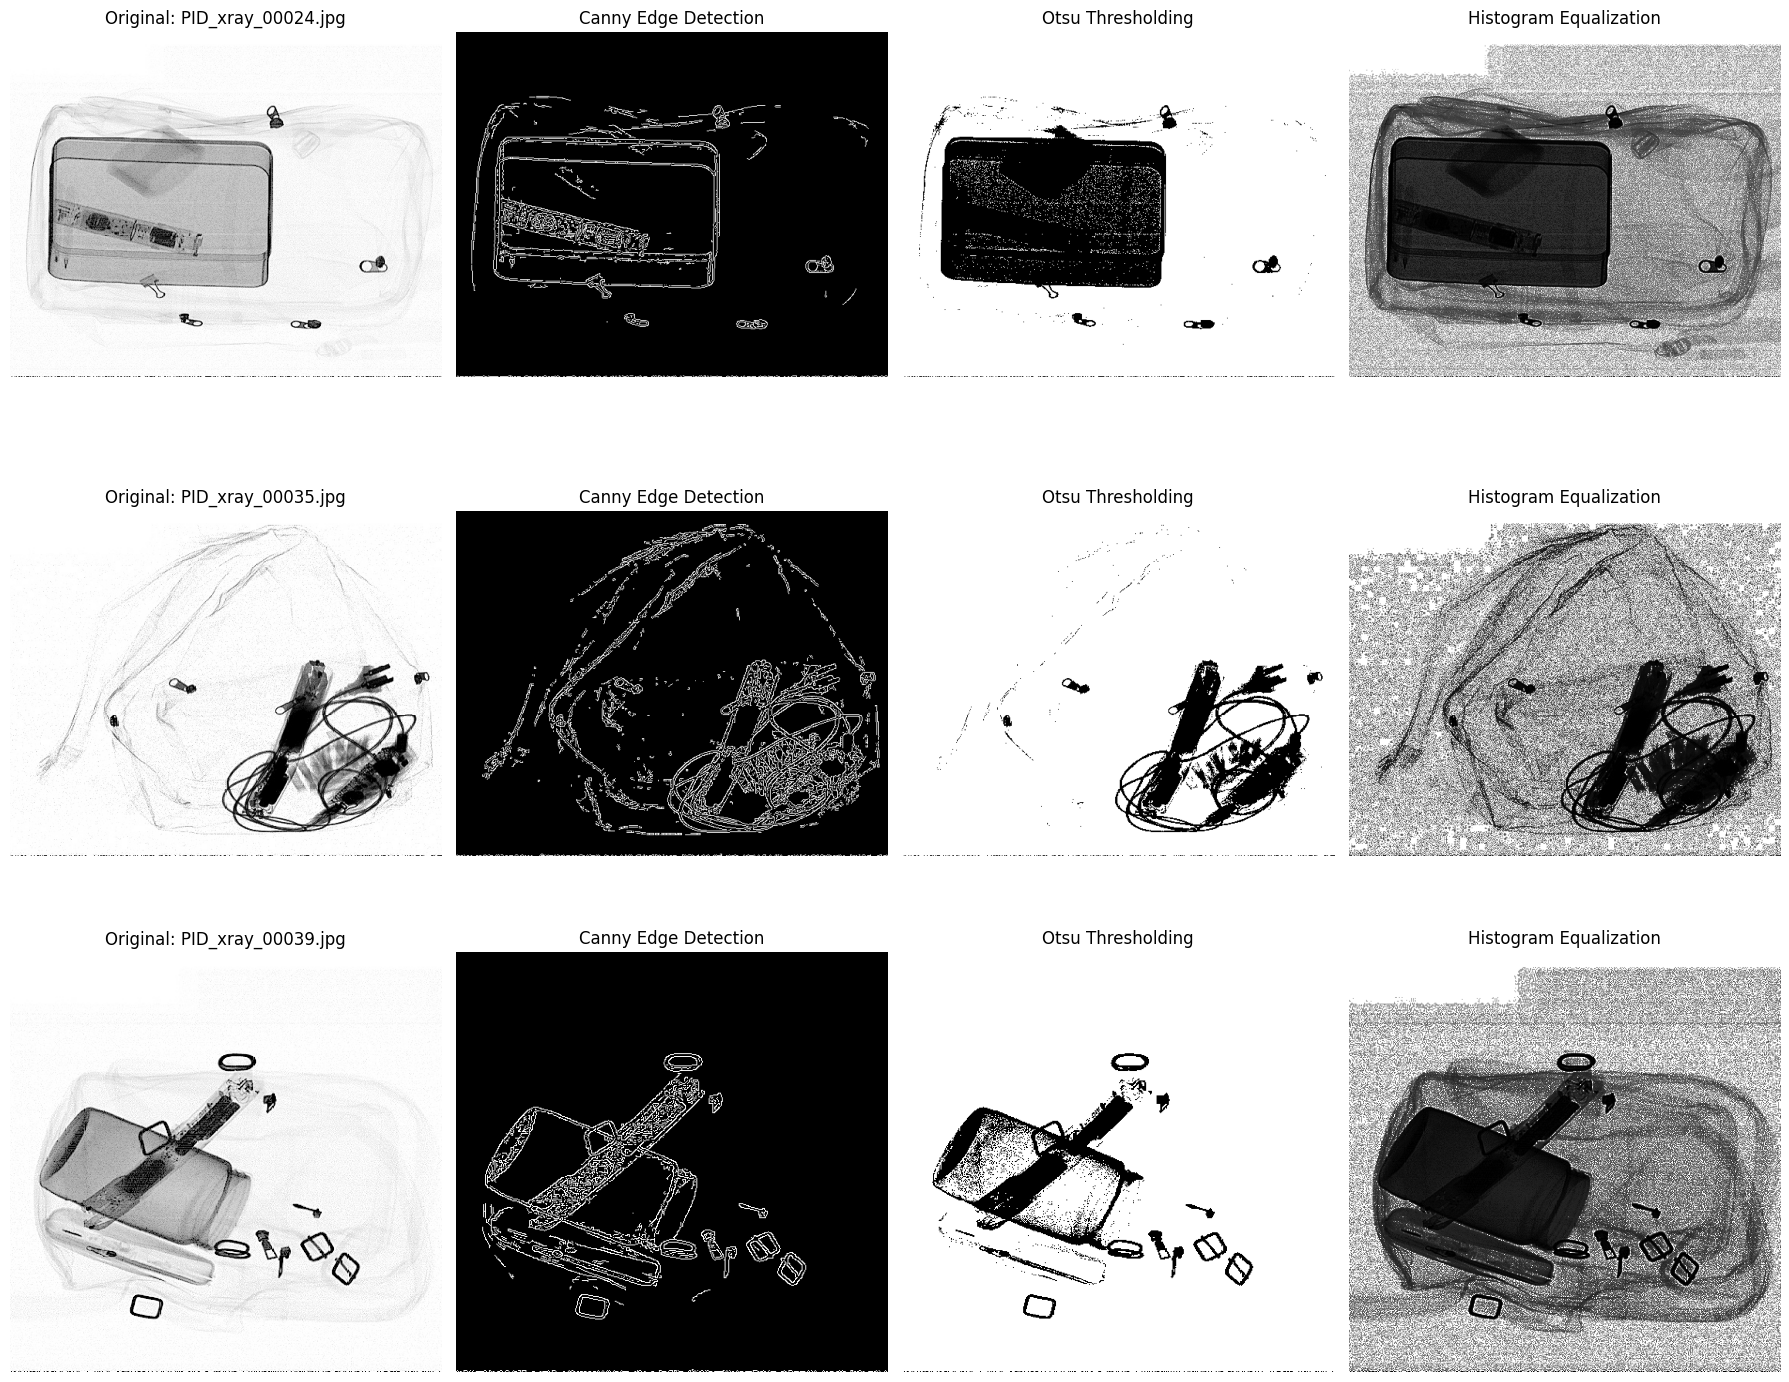

In [6]:
def cv_advanced_analysis(root_path, name, num_samples=3):
    """
    Se conserva el análisis visual original, pero la estimación de dimensiones
    ya no se hace sobre una muestra, sino sobre todas las imágenes legibles.
    """
    print(f"\n{'='*80}")
    print(f"Advanced CV analysis: {name}")
    print(f"{'='*80}")

    root = Path(root_path)
    image_paths = get_all_image_paths(root)

    if not image_paths:
        print("No images found.")
        return

    dims = []
    readable_images = []

    for p in image_paths:
        img = cv.imread(str(p))
        if img is not None:
            dims.append(img.shape[:2])
            readable_images.append(p)

    if not dims:
        print("No readable images found.")
        return

    avg_h = np.mean([d[0] for d in dims])
    avg_w = np.mean([d[1] for d in dims])

    print(f"Average dimensions (all readable images): {avg_w:.1f} x {avg_h:.1f}")
    print(f"Unique image shapes: {len(set(dims))}")

    num_samples = min(num_samples, len(readable_images))
    fig, axes = plt.subplots(num_samples, 4, figsize=(18, 5 * num_samples))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        img_path = readable_images[i]
        img = safe_read_gray(img_path)
        if img is None:
            continue

        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title(f"Original: {img_path.name}")

        edges = cv.Canny(img, 100, 200)
        axes[i, 1].imshow(edges, cmap="gray")
        axes[i, 1].set_title("Canny Edge Detection")

        _, thresh = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
        axes[i, 2].imshow(thresh, cmap="gray")
        axes[i, 2].set_title("Otsu Thresholding")

        # Se añade ecualización de histograma como referencia útil de contraste.
        equalized = cv.equalizeHist(img)
        axes[i, 3].imshow(equalized, cmap="gray")
        axes[i, 3].set_title("Histogram Equalization")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()


cv_advanced_analysis(anomaly_path, "Anomaly Dataset")
cv_advanced_analysis(contraband_path, "Contraband Dataset")

## **7. Perfilamiento de anotaciones YOLO si existen labels**


YOLO label analysis: Anomaly Dataset
Total .txt files found: 8832
Valid YOLO label files: 8830
Empty label files: 0
Malformed/non-YOLO files: 2

Examples of malformed/non-YOLO files:
/root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/README.dataset.txt
/root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/README.roboflow.txt

Class distribution:


,class_id,n_boxes
0,0,1841
1,1,1975
2,2,1041
3,3,1948
4,4,2025


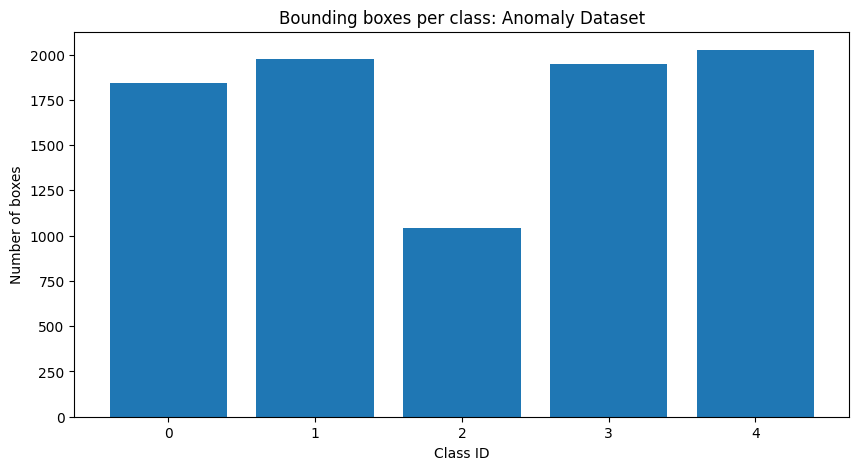

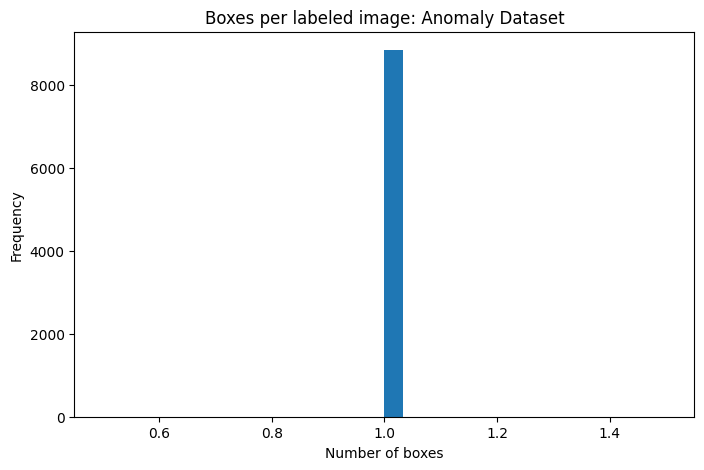

Average boxes per labeled image: 1.00
Median boxes per labeled image: 1.00


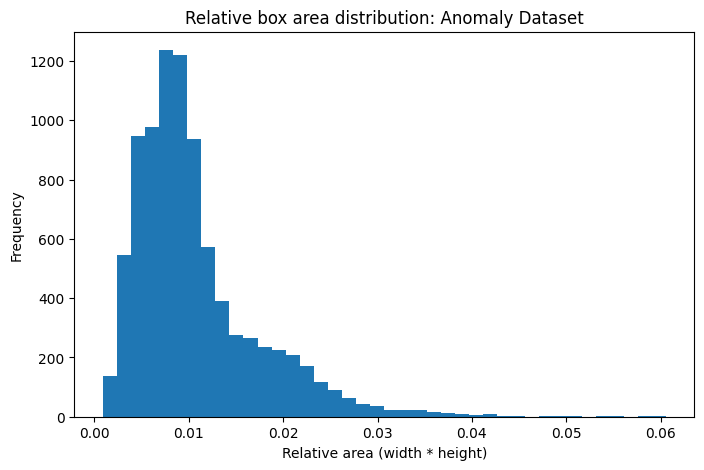

Average relative box area: 0.0107
Median relative box area: 0.0090

YOLO label analysis: Contraband Dataset
Total .txt files found: 13713
Valid YOLO label files: 13713
Empty label files: 0
Malformed/non-YOLO files: 0

Class distribution:


,class_id,n_boxes
0,0,1488
1,1,1499
2,2,1508
3,3,1510
4,4,1511
5,5,1495
6,6,1519
7,7,1499
8,8,1495
9,9,1501


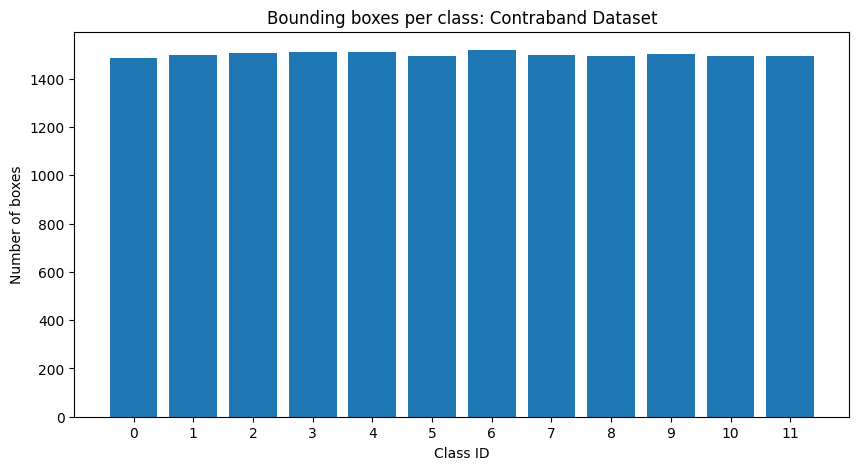

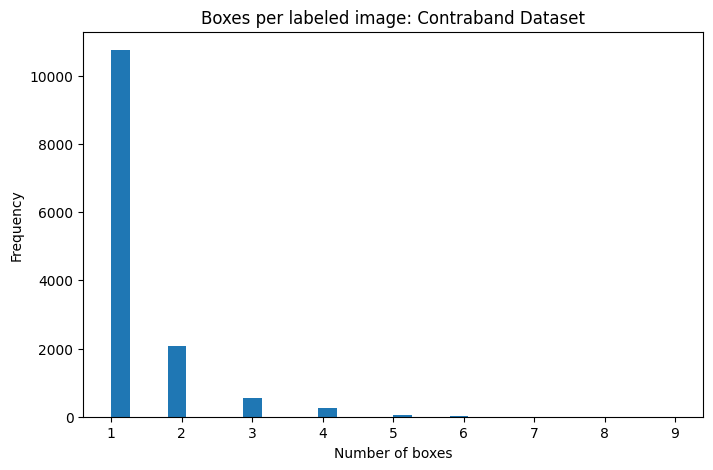

Average boxes per labeled image: 1.31
Median boxes per labeled image: 1.00


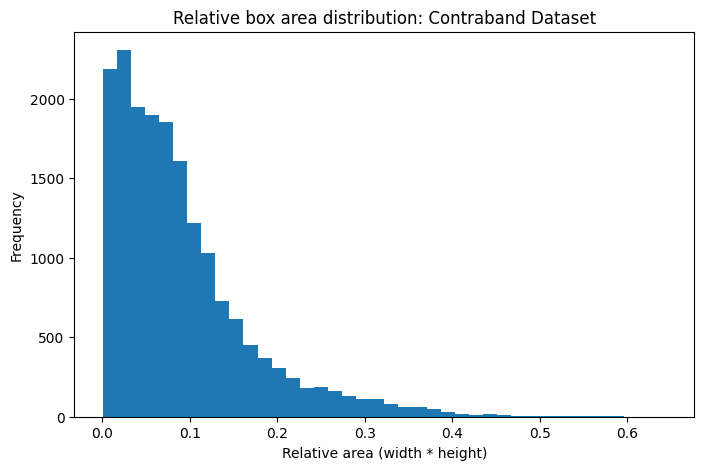

Average relative box area: 0.0905
Median relative box area: 0.0707


In [7]:
def analyze_yolo_labels(root_path, name):
    """
    Se analiza la estructura de anotaciones YOLO si el dataset contiene archivos .txt
    con el formato: class_id x_center y_center width height.
    """
    print(f"\n{'='*80}")
    print(f"YOLO label analysis: {name}")
    print(f"{'='*80}")

    label_files = find_label_files(root_path)

    if not label_files:
        print("No candidate .txt label files were found.")
        return None

    class_counts = Counter()
    boxes_per_image = []
    relative_box_areas = []
    malformed_files = []
    empty_label_files = 0

    valid_label_files = 0

    for lbl_path in label_files:
        try:
            lines = lbl_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
        except Exception:
            malformed_files.append(str(lbl_path))
            continue

        if len(lines) == 0:
            empty_label_files += 1
            continue

        current_boxes = 0
        file_is_valid = False

        for line in lines:
            parts = line.strip().split()

            # Se valida el formato YOLO estándar.
            if len(parts) != 5:
                continue

            try:
                class_id = int(float(parts[0]))
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
            except Exception:
                continue

            file_is_valid = True
            current_boxes += 1
            class_counts[class_id] += 1
            relative_box_areas.append(width * height)

        if file_is_valid:
            valid_label_files += 1
            boxes_per_image.append(current_boxes)
        else:
            malformed_files.append(str(lbl_path))

    print(f"Total .txt files found: {len(label_files)}")
    print(f"Valid YOLO label files: {valid_label_files}")
    print(f"Empty label files: {empty_label_files}")
    print(f"Malformed/non-YOLO files: {len(malformed_files)}")

    if malformed_files:
        print("\nExamples of malformed/non-YOLO files:")
        for p in malformed_files[:10]:
            print(p)
        if len(malformed_files) > 10:
            print(f"... and {len(malformed_files) - 10} more")

    if class_counts:
        class_df = (
            pd.DataFrame(
                [{"class_id": k, "n_boxes": v} for k, v in class_counts.items()]
            )
            .sort_values("class_id")
            .reset_index(drop=True)
        )

        print("\nClass distribution:")
        display(class_df)

        plt.figure(figsize=(10, 5))
        plt.bar(class_df["class_id"].astype(str), class_df["n_boxes"])
        plt.title(f"Bounding boxes per class: {name}")
        plt.xlabel("Class ID")
        plt.ylabel("Number of boxes")
        plt.show()

    if boxes_per_image:
        plt.figure(figsize=(8, 5))
        plt.hist(boxes_per_image, bins=30)
        plt.title(f"Boxes per labeled image: {name}")
        plt.xlabel("Number of boxes")
        plt.ylabel("Frequency")
        plt.show()

        print(f"Average boxes per labeled image: {np.mean(boxes_per_image):.2f}")
        print(f"Median boxes per labeled image: {np.median(boxes_per_image):.2f}")

    if relative_box_areas:
        plt.figure(figsize=(8, 5))
        plt.hist(relative_box_areas, bins=40)
        plt.title(f"Relative box area distribution: {name}")
        plt.xlabel("Relative area (width * height)")
        plt.ylabel("Frequency")
        plt.show()

        print(f"Average relative box area: {np.mean(relative_box_areas):.4f}")
        print(f"Median relative box area: {np.median(relative_box_areas):.4f}")

    return {
        "class_counts": class_counts,
        "boxes_per_image": boxes_per_image,
        "relative_box_areas": relative_box_areas,
        "malformed_files": malformed_files
    }


anomaly_labels = analyze_yolo_labels(anomaly_path, "Anomaly Dataset")
contraband_labels = analyze_yolo_labels(contraband_path, "Contraband Dataset")

## **8. Comparación entre los dos 2 datasets**

In [8]:
def compare_dataset_summaries(anomaly_stats, contraband_stats):
    """
    Se consolidan los resúmenes principales de ambos datasets
    para facilitar la comparación directa.
    """
    print(f"\n{'='*80}")
    print("Consolidated comparison")
    print(f"{'='*80}")

    summary_frames = []

    if anomaly_stats is not None:
        summary_frames.append(anomaly_stats["summary"])

    if contraband_stats is not None:
        summary_frames.append(contraband_stats["summary"])

    if not summary_frames:
        print("No summaries available.")
        return None

    comparison_df = pd.concat(summary_frames, ignore_index=True)
    display(comparison_df)

    return comparison_df


comparison_df = compare_dataset_summaries(anomaly_stats, contraband_stats)


Consolidated comparison


,dataset,total_images_found,total_images_readable,total_images_corrupt,exact_duplicate_files,global_mean_brightness,global_std_brightness,global_mean_contrast_rms,global_std_contrast_rms,global_mean_entropy,global_mean_blur_laplacian,global_mean_edge_density,avg_height,avg_width,median_height,median_width,avg_aspect_ratio,unique_shapes
0,Anomaly Dataset,8830,8830,0,0,233.627153,8.559916,39.614509,8.386054,3.350966,1268.324172,0.044710,416.000000,416.000000,416.0,416.0,1.000000,1
1,Contraband Dataset,13728,13728,0,17,219.323415,17.719275,57.647088,14.452052,4.532667,2578.085098,0.052136,482.976836,497.655522,448.0,457.5,1.031976,1579


## **9. Exportación de resultados**

In [9]:
def export_analysis_results(anomaly_stats, contraband_stats, output_dir="eda_outputs"):
    """
    Se exportan estadísticas descriptivas a CSV para facilitar revisión posterior
    y para compartir resultados resumidos.
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    if anomaly_stats is not None:
        anomaly_stats["summary"].to_csv(output_path / "anomaly_summary.csv", index=False)
        anomaly_stats["metrics"].to_csv(output_path / "anomaly_metrics.csv", index=False)

    if contraband_stats is not None:
        contraband_stats["summary"].to_csv(output_path / "contraband_summary.csv", index=False)
        contraband_stats["metrics"].to_csv(output_path / "contraband_metrics.csv", index=False)

    if "comparison_df" in globals() and comparison_df is not None:
        comparison_df.to_csv(output_path / "datasets_comparison.csv", index=False)

    print(f"Results exported to: {output_path.resolve()}")


export_analysis_results(anomaly_stats, contraband_stats)

Results exported to: /content/eda_outputs
